In [4]:
import glob
import random
import numpy as np
import matplotlib.pyplot as plt

time = ['1 days', '2 days', '4 days', '7 days', '11 days', '17 days',
        '25 days', '37 days', '53 days', '77 days', '111 days', '158 days',
        '226 days', '323 days', '1.3 years', '1.8 years', '2.6 years',
        '3.6 years', '5.2 years', '7.3 years', '10.4 years', '14.8 years',
        '21.1 years', '30.0 years']

plt.rcParams["figure.figsize"] = (14, 8)
plt.rcParams["image.cmap"] = "jet"

all_files = sorted(glob.glob(r"C:\Users\KirstyLocal\Projects\co2-plume-operator-learning\dataset\train_data\*.npz"))
print(f"Found {len(all_files)} training files")

Found 4500 training files


In [5]:
# Pick one example sample
sample_idx = 3
sample_path = all_files[sample_idx]

with np.load(sample_path) as data:
    print(data.files)
    porosity = data["porosity"]
    perm_r = data["perm_r"]
    perm_z = data["perm_z"]
    inj_rate = data["inj_rate"]
    temperature = data["temperature"]
    depth = data["depth"]
    Swi = data["Swi"]
    lam = data["lam"]
    perf_interval = data["perf_interval"]
    gas_saturation = data["gas_saturation"]
    pressure_buildup = data["pressure_buildup"]

nz = porosity.shape[0]

print("Sample path:", sample_path)
print("reservoir dimension is:", porosity.shape)
print("gas saturation dimension is:", gas_saturation.shape)
print("pressure buildup dimension is:", pressure_buildup.shape)
print("inj_rate:", inj_rate)
print("temperature:", temperature)
print("depth:", depth)
print("Swi:", Swi)
print("lam:", lam)
print("perf_interval:", perf_interval)

['porosity', 'perm_r', 'perm_z', 'inj_rate', 'temperature', 'depth', 'Swi', 'lam', 'perf_interval', 'pressure_buildup', 'gas_saturation']
Sample path: C:\Users\KirstyLocal\Projects\co2-plume-operator-learning\dataset\train_data\data_0003.npz
reservoir dimension is: (32, 200)
gas saturation dimension is: (32, 200, 24)
pressure buildup dimension is: (32, 200, 24)
inj_rate: 1.3823853637509944
temperature: 71.12895280122757
depth: 292.1177268028259
Swi: 0.15719308853149416
lam: 0.5664589405059814
perf_interval: [10 31]


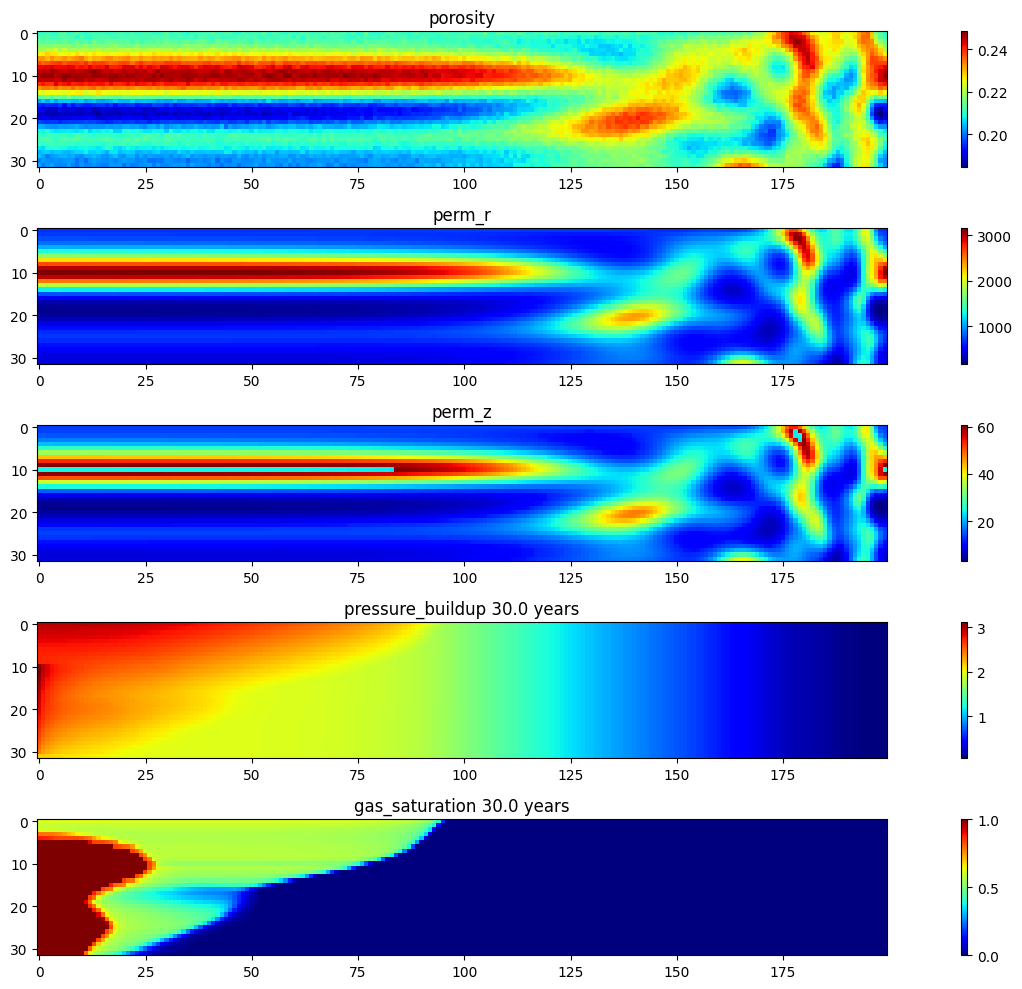

In [6]:
# Starter-style image plots on the indexed grid
plt.figure(figsize=(15, 10))

plt.subplot(5, 1, 1)
plt.imshow(porosity[:, :])
plt.colorbar()
plt.title("porosity")

plt.subplot(5, 1, 2)
plt.imshow(perm_r[:, :])
plt.colorbar()
plt.title("perm_r")

plt.subplot(5, 1, 3)
plt.imshow(perm_z[:, :])
plt.colorbar()
plt.title("perm_z")

plt.subplot(5, 1, 4)
plt.imshow(pressure_buildup[:, :, -1])
plt.colorbar()
plt.title(f"pressure_buildup {time[-1]}")

plt.subplot(5, 1, 5)
plt.imshow(gas_saturation[:, :, -1])
plt.colorbar()
plt.title(f"gas_saturation {time[-1]}")

plt.tight_layout()
plt.show()

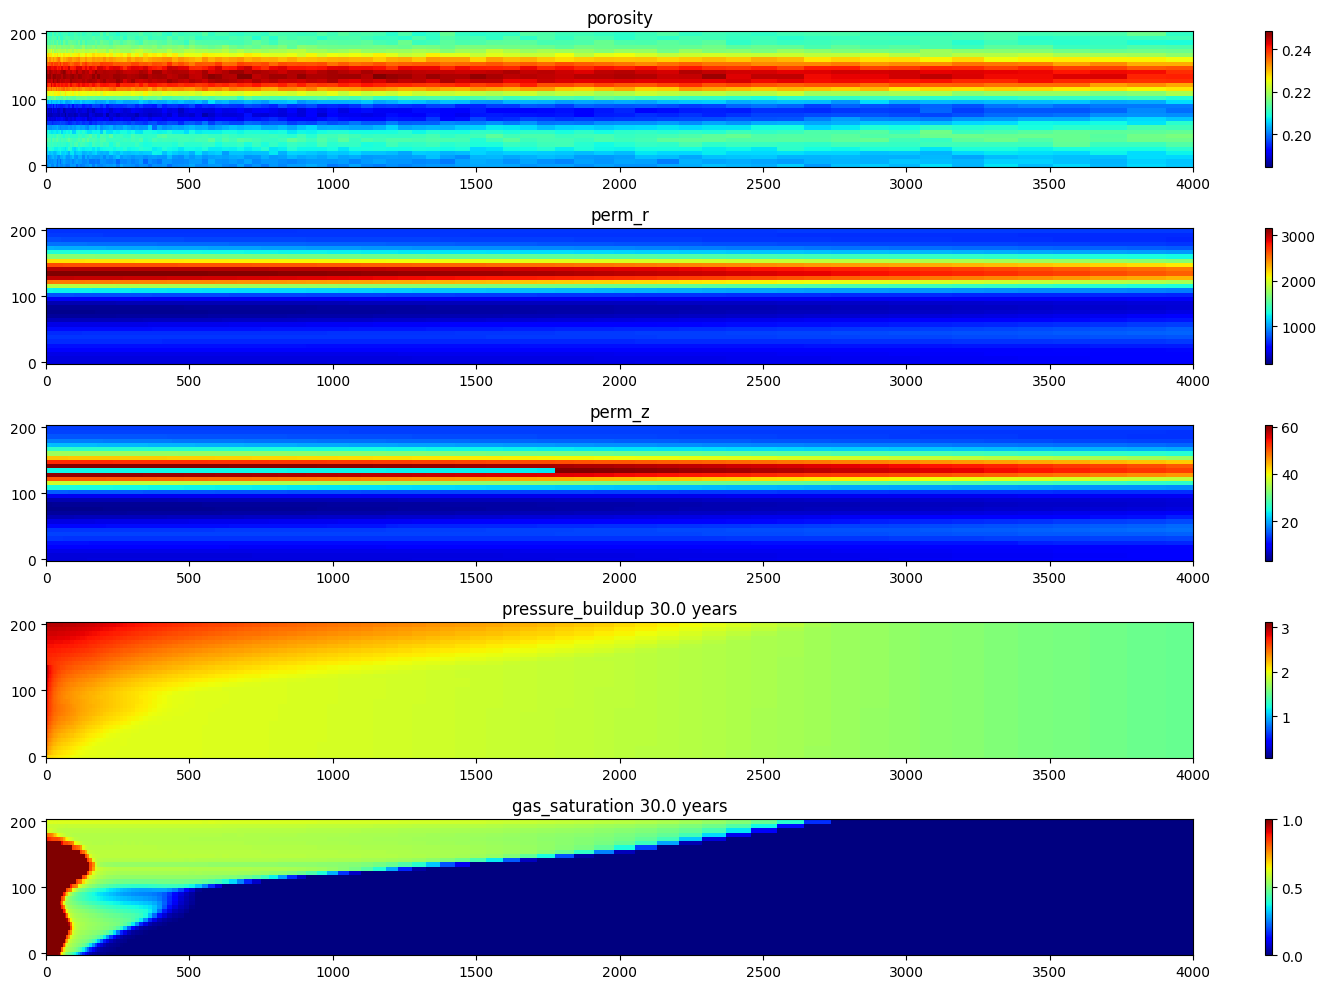

In [7]:
# Convert data to real spatial dimensions for better visualisation
dx = np.cumsum(3.5938 * np.power(1.035012, range(200))) + 0.1
X, Y = np.meshgrid(dx, np.linspace(0, 200, num=nz))

def pcolor(x):
    plt.jet()
    plt.xlim([0, 4000])
    return plt.pcolor(X, Y, np.flipud(x))

plt.figure(figsize=(15, 10))

plt.subplot(5, 1, 1)
pcolor(porosity[:, :])
plt.colorbar()
plt.title("porosity")

plt.subplot(5, 1, 2)
pcolor(perm_r[:, :])
plt.colorbar()
plt.title("perm_r")

plt.subplot(5, 1, 3)
pcolor(perm_z[:, :])
plt.colorbar()
plt.title("perm_z")

plt.subplot(5, 1, 4)
pcolor(pressure_buildup[:, :, -1])
plt.colorbar()
plt.title(f"pressure_buildup {time[-1]}")

plt.subplot(5, 1, 5)
pcolor(gas_saturation[:, :, -1])
plt.colorbar()
plt.title(f"gas_saturation {time[-1]}")

plt.tight_layout()
plt.show()

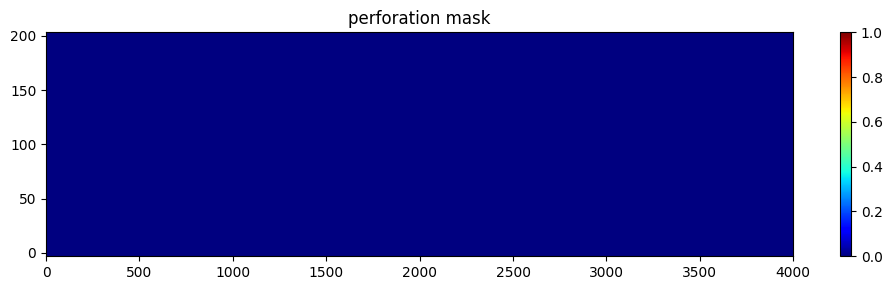

In [8]:
# Visualise the perforation interval as a mask
perf_mask = np.zeros_like(porosity)
z0, z1 = int(perf_interval[0]), int(perf_interval[1])
perf_mask[z0:z1+1, 0] = 1.0

plt.figure(figsize=(10, 3))
pcolor(perf_mask)
plt.colorbar()
plt.title("perforation mask")
plt.tight_layout()
plt.show()

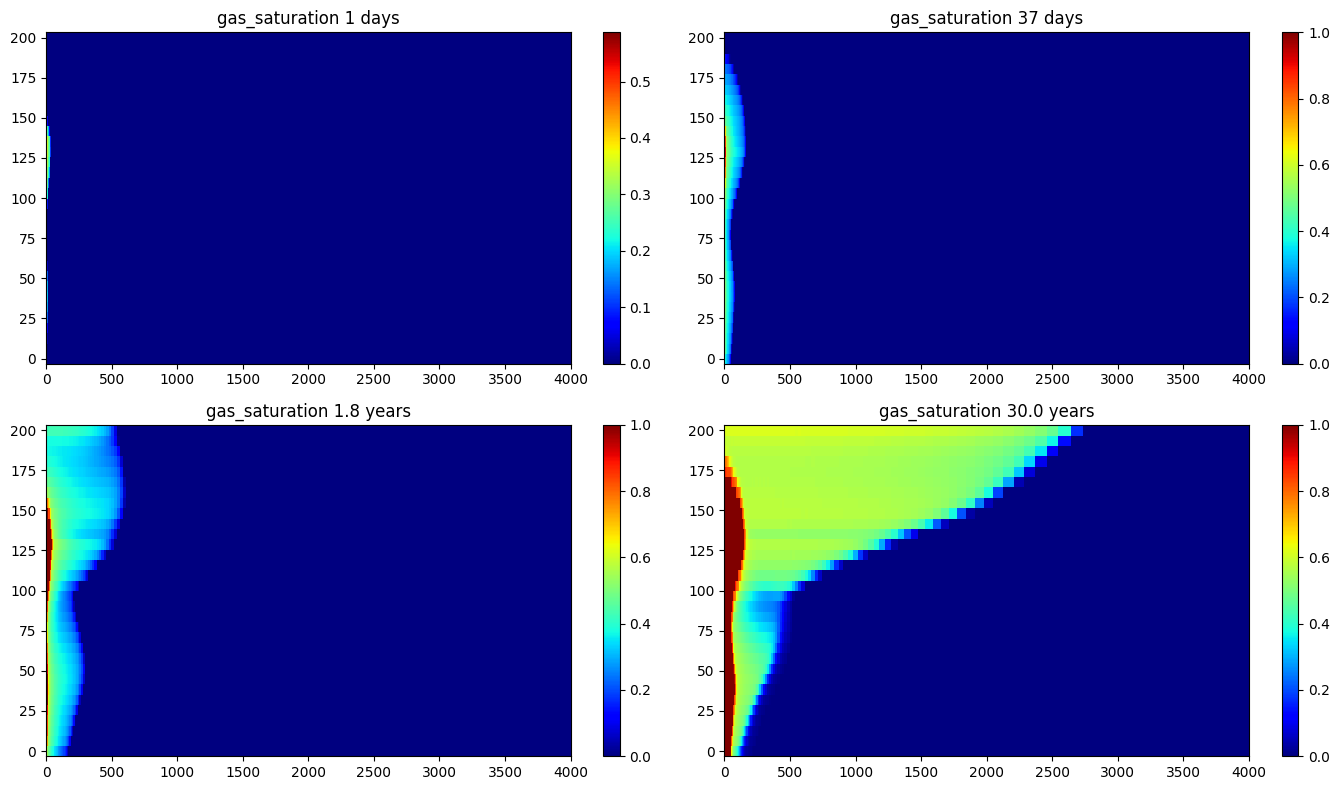

In [9]:
# Show gas saturation snapshots at selected times
selected_times = [0, 7, 15, 23]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.ravel()

for ax, t_idx in zip(axes, selected_times):
    plt.sca(ax)
    pcolor(gas_saturation[:, :, t_idx])
    plt.colorbar(ax=ax)
    ax.set_title(f"gas_saturation {time[t_idx]}")

plt.tight_layout()
plt.show()

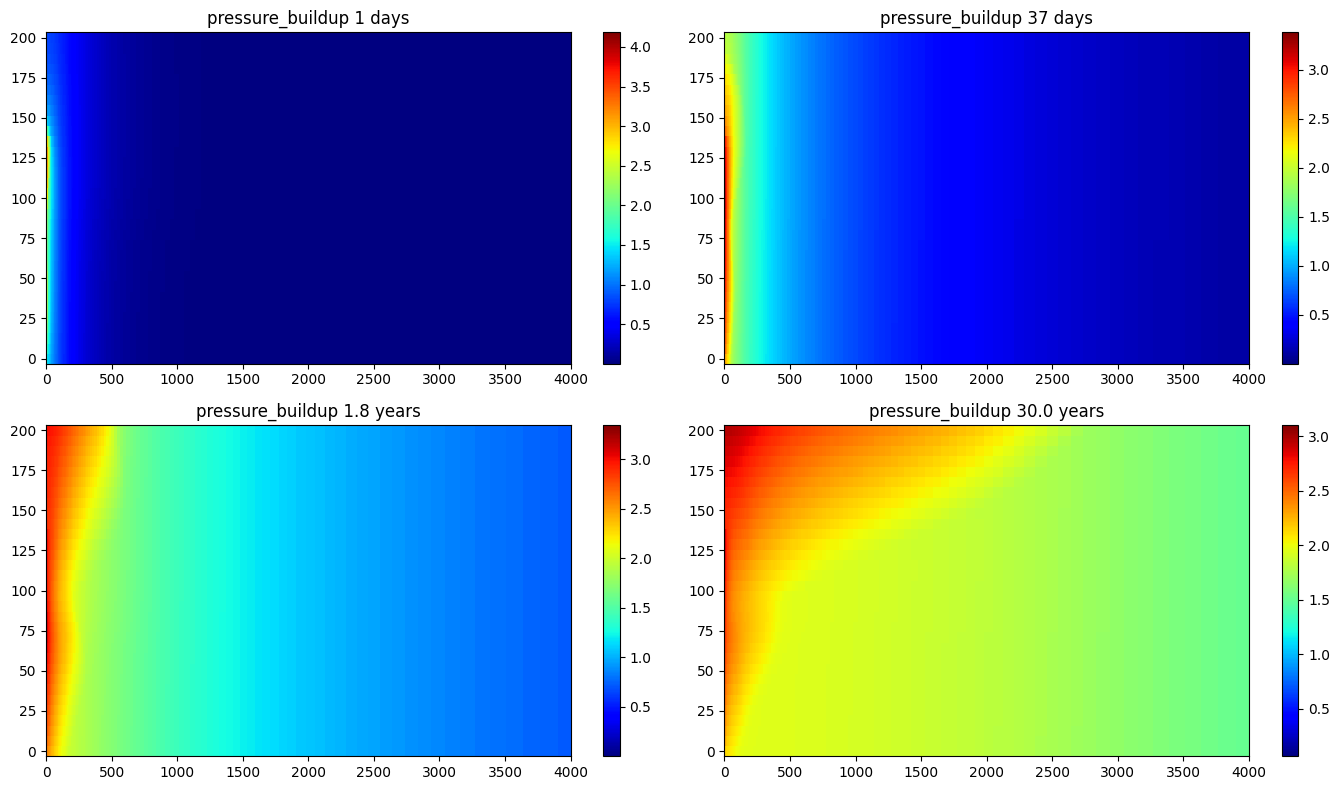

In [10]:
# Show pressure buildup snapshots at selected times
selected_times = [0, 7, 15, 23]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.ravel()

for ax, t_idx in zip(axes, selected_times):
    plt.sca(ax)
    pcolor(pressure_buildup[:, :, t_idx])
    plt.colorbar(ax=ax)
    ax.set_title(f"pressure_buildup {time[t_idx]}")

plt.tight_layout()
plt.show()

In [11]:
# Quick scalar summary from a random subset of training samples
rng = random.Random(42)
subset_files = all_files.copy()
rng.shuffle(subset_files)
subset_files = subset_files[:200]

summary = {
    "inj_rate": [],
    "temperature": [],
    "depth": [],
    "Swi": [],
    "lam": [],
    "porosity_mean": [],
    "perm_r_mean": [],
    "perm_z_mean": [],
    "gas_max_final": [],
    "pressure_max_final": [],
}

for file_path in subset_files:
    with np.load(file_path) as data:
        summary["inj_rate"].append(float(data["inj_rate"]))
        summary["temperature"].append(float(data["temperature"]))
        summary["depth"].append(float(data["depth"]))
        summary["Swi"].append(float(data["Swi"]))
        summary["lam"].append(float(data["lam"]))
        summary["porosity_mean"].append(float(data["porosity"].mean()))
        summary["perm_r_mean"].append(float(data["perm_r"].mean()))
        summary["perm_z_mean"].append(float(data["perm_z"].mean()))
        summary["gas_max_final"].append(float(data["gas_saturation"][:, :, -1].max()))
        summary["pressure_max_final"].append(float(data["pressure_buildup"][:, :, -1].max()))

for key, values in summary.items():
    arr = np.asarray(values)
    print(f"{key:20s} min={arr.min():10.4f} max={arr.max():10.4f} mean={arr.mean():10.4f} std={arr.std():10.4f}")

inj_rate             min=    0.2092 max=    1.9810 mean=    1.0857 std=    0.5165
temperature          min=   32.9636 max=  164.6049 mean=   83.7330 std=   30.8175
depth                min=  101.7973 max=  297.8394 mean=  198.7243 std=   57.4593
Swi                  min=    0.1002 max=    0.2998 mean=    0.1949 std=    0.0581
lam                  min=    0.3010 max=    0.6994 mean=    0.5093 std=    0.1187
porosity_mean        min=    0.1038 max=    0.2508 mean=    0.1682 std=    0.0356
perm_r_mean          min=    1.2519 max= 3711.8313 mean=  355.9956 std=  620.5207
perm_z_mean          min=    0.0251 max=  528.7513 mean=   10.2135 std=   40.5977
gas_max_final        min=    0.7215 max=    1.0000 mean=    0.9878 std=    0.0522
pressure_max_final   min=    0.7275 max=  385.1022 mean=   79.2180 std=  100.8242


In [13]:
print(gas.shape)
print(pressure.shape)

(51, 200)
(51, 200)


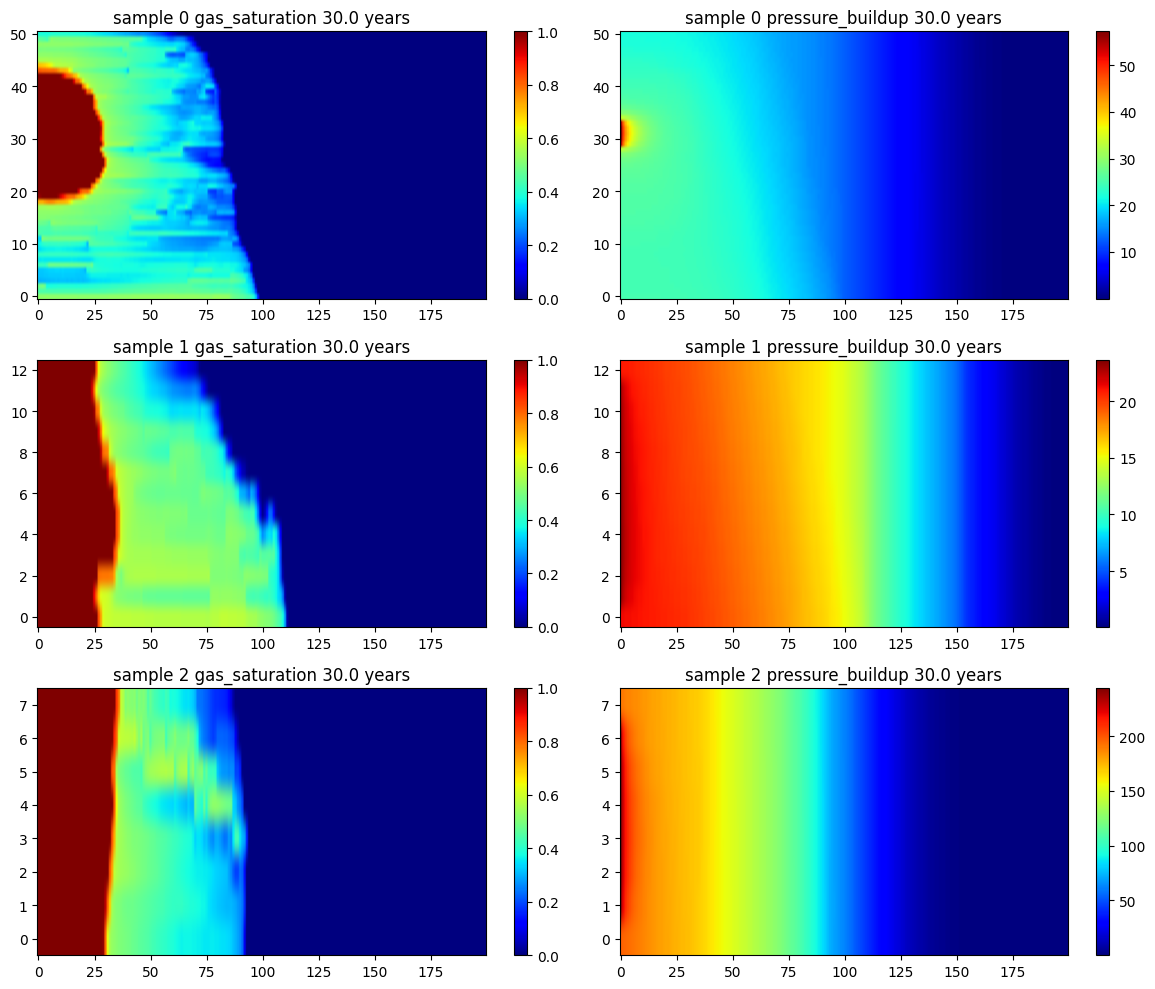

In [14]:
compare_indices = [0, 1, 2]
fig, axes = plt.subplots(len(compare_indices), 2, figsize=(12, 10))

for row, idx in enumerate(compare_indices):
    with np.load(all_files[idx]) as data:
        gas = data["gas_saturation"][:, :, -1]
        pressure = data["pressure_buildup"][:, :, -1]

    im0 = axes[row, 0].imshow(gas, origin="lower", aspect="auto", cmap="jet")
    fig.colorbar(im0, ax=axes[row, 0])
    axes[row, 0].set_title(f"sample {idx} gas_saturation {time[-1]}")

    im1 = axes[row, 1].imshow(pressure, origin="lower", aspect="auto", cmap="jet")
    fig.colorbar(im1, ax=axes[row, 1])
    axes[row, 1].set_title(f"sample {idx} pressure_buildup {time[-1]}")

plt.tight_layout()
plt.show()